In [20]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = False # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: False, Database: kaggle


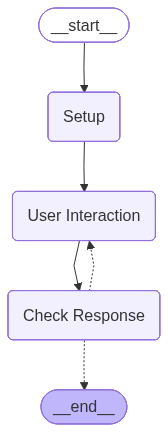

In [22]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]
    try: 
        # Se o experimento já foi avaliado, pula para o próximo
        if exp_id in processed_ids:
            print(f"Pulando experimento {exp_id} já processado.")
            continue

        print(f"Processando experimento {exp_id}...")

        config =  {"recursion_limit": 50}
        # Invoca a avaliação com as configurações estendidas
        eval_result = eval_graph.invoke({
            "experiment": experiment,
            "max_retries": 2,
            "debug_mode": True,
            "model_version": model_version,
            "experiment_type": experiment_type,
           
        }, config=config)

        print("Experimento avaliado:\n", eval_result["experiment_eval"])

        # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
        evals.append({
            "experiment_id": exp_id,
            "experiment_config": eval_result.get("experiment_config", {
                "max_retries": 2,
                "model_version": model_version,
                "timestamp": datetime.now().isoformat(),
                "experiment_type": experiment_type
            }),
            "experiment_eval": eval_result["experiment_eval"]
        })

        # Atualiza o arquivo salvando o resultado atual
        with open(evals_filename, 'w', encoding='utf-8') as f:
            json.dump(evals, f, indent=4)
    except Exception as e:
        print(f"Erro ao processar experimento {exp_id}: {e}")
        with open(evals_filename, 'w', encoding='utf-8') as f:
            json.dump(evals, f, indent=4)

Processando experimento 1...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  Who are the players inducted into the hall of fame and their birth details?


c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Who are the players inducted into the hall of fame and their birth details?",
    "schema_linking": ["THEHISTORYOFBASEBALL_HALL_OF_FAME", "THEHISTORYOFBASEBALL_PLAYER"],
    "answer": "There are 312 players inducted into the Hall of Fame. For example:\n1. Hank Aaron: Born in 1934 (February 5th) in Mobile, Alabama, USA.\n2. Roberto Alomar: Born in 1968 (February 5th) in Ponce, Puerto Rico.\n3. Walter Alston: Born in 1911 (December 1st) in Venice, Ohio, USA.\n\nPlease specify if you would like details on more players.",
    "sql": "SELECT p.name_first, p.name_last, p.birth_year, p.birth_state, p.birth_month, p.birth_day, p.birth_country, p.birth_city\nFROM kaggle.thehistoryofbaseball_hall_of_fame h\nJOIN kaggle.thehistoryofbaseball_player p\nON h.player_id = p.player_id\nWHERE LOWER(h.inducted) = 'y';"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Who

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


True cols: Index(['NAME_FIRST', 'NAME_LAST', 'BIRTH_YEAR', 'BIRTH_MONTH', 'BIRTH_DAY',
       'BIRTH_CITY', 'BIRTH_STATE', 'BIRTH_COUNTRY'],
      dtype='object')
Adj. True cols: Index(['NAME_FIRST', 'NAME_LAST', 'BIRTH_YEAR', 'BIRTH_MONTH', 'BIRTH_DAY',
       'BIRTH_CITY', 'BIRTH_STATE', 'BIRTH_COUNTRY'],
      dtype='object')
Predicted cols: Index(['NAME_FIRST', 'NAME_LAST', 'BIRTH_YEAR', 'BIRTH_STATE', 'BIRTH_MONTH',
       'BIRTH_DAY', 'BIRTH_COUNTRY', 'BIRTH_CITY'],
      dtype='object')
Adj. Predicted cols: Index(['NAME_FIRST', 'NAME_LAST', 'BIRTH_YEAR', 'BIRTH_MONTH', 'BIRTH_DAY',
       'BIRTH_CITY', 'BIRTH_STATE', 'BIRTH_COUNTRY'],
      dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 1, 'original_intent': 'Find the players inducted into the hall of fame and their birth details.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'Who are the players inducted into the hall of fame and their birth details?', 'agent_r

...

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "What was the average number of votes required for induction in 1936?",
    "schema_linking": ["THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "The average number of votes required for induction in 1936 was approximately 109.45.",
    "sql": "SELECT AVG(NEEDED) AS avg_votes_required FROM KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME WHERE YEARID = 1936"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "What was the average number of votes required for induction in 1936?",
    "schema_linking": ["THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "The average number of votes required for induction in 1936 was approximately 109.45.",
    "sql": "SELECT AVG(NEEDED) AS avg_votes_required FROM KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME WHERE YEARID = 1936"
}.

[INFO] Avaliando o resultado: {'input': 'What was the average number of votes required for induction in

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Which team did they play for according to their salary records?",
    "schema_linking": "",
    "answer": "Can you clarify who 'they' refers to? Please provide the player's name or additional details.",
    "sql": ""
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Which team did they play for according to their salary records?",
    "schema_linking": "",
    "answer": "Can you clarify who 'they' refers to? Please provide the player's name or additional details.",
    "sql": ""
}.

[INFO] Avaliando o resultado: {'input': 'Which team did they play for according to their salary records?', 'schema_linking': '', 'answer': "Can you clarify who 'they' refers to? Please provide the player's name or additional details.", 'sql': ''}.

[AI as JUDGE] Judging if a feedback is needed for the last message in chat history.
[AI as JUDGE] Result: True.
[Schema Linking 

GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/GRAPH_RECURSION_LIMIT

Pulando experimento 1 já processado.
Pulando experimento 2 já processado.
Pulando experimento 3 já processado.
Pulando experimento 4 já processado.
Pulando experimento 5 já processado.
Pulando experimento 6 já processado.
Pulando experimento 7 já processado.
Processando experimento 8...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  How many players were inducted into the Hall of Fame in 1936?


c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "How many players were inducted into the Hall of Fame in 1936?",
    "schema_linking": ["KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "5 players were inducted into the Hall of Fame in 1936.",
    "sql": "SELECT COUNT(*) AS players_inducted FROM KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME WHERE YEARID = 1936 AND LOWER(INDUCTED) = 'y'"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "How many players were inducted into the Hall of Fame in 1936?",
    "schema_linking": ["KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "5 players were inducted into the Hall of Fame in 1936.",
    "sql": "SELECT COUNT(*) AS players_inducted FROM KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME WHERE YEARID = 1936 AND LOWER(INDUCTED) = 'y'"
}.

[INFO] Avaliando o resultado: {'input': 'How many players were inducted into the Hall of Fame in 1936?', 'schema_linking'

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


True cols: Index(['COUNT(*)'], dtype='object')
Adj. True cols: Index(['COUNT(*)'], dtype='object')
Predicted cols: Index(['PLAYERS_INDUCTED'], dtype='object')
Adj. Predicted cols: Index(['PLAYERS_INDUCTED'], dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 1, 'original_intent': 'Count the number of players inducted into the Hall of Fame in 1936.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'How many players were inducted into the Hall of Fame in 1936?', 'agent_reply': '5 players were inducted into the Hall of Fame in 1936.', 'evaluation': {'text_to_sql_input': 'How many players were inducted into the Hall of Fame in 1936?', 'user_intention': 'Count the number of players inducted into the Hall of Fame in 1936.', 'recall': 0.0, 'alignment': True, 'correctness': True, 'expected_sql': "SELECT COUNT(*) FROM THEHISTORYOFBASEBALL_HALL_OF_FAME WHERE YEARID = 1936 AND INDUCTED = 'Y'", 'generated_sql': "SELECT COUNT(*) AS players

...

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "I am asking about the most frequent category among inducted players in the identified year.",
    "schema_linking": ["THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "The most frequent category among inducted players is provided for each year. For example, in 1936, the most frequent category was 'Player' with 5 inductees. In 1937, 'Pioneer/Executive' and 'Player' both had 3 inductees each. In 2014, 'Player' and 'Manager' had 3 inductees each. For a specific year, feel free to ask.",
    "sql": "SELECT yearid, category, COUNT(*) AS count_of_inducted FROM kaggle.thehistoryofbaseball_hall_of_fame WHERE LOWER(inducted) = 'y' GROUP BY yearid, category ORDER BY yearid, count_of_inducted DESC"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "I am asking about the most frequent category among inducted players in the identified year.",
    "schema_linking": 

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Who voted for the inducted players in that year the most?",
    "schema_linking": "",
    "answer": "Could you clarify which year you are referring to? Your question contains a reference ('that year') that needs to be resolved.",
    "sql": ""
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Who voted for the inducted players in that year the most?",
    "schema_linking": "",
    "answer": "Could you clarify which year you are referring to? Your question contains a reference ('that year') that needs to be resolved.",
    "sql": ""
}.

[INFO] Avaliando o resultado: {'input': 'Who voted for the inducted players in that year the most?', 'schema_linking': '', 'answer': "Could you clarify which year you are referring to? Your question contains a reference ('that year') that needs to be resolved.", 'sql': ''}.

[AI as JUDGE] Judging if a feedback is needed f

TypeError: the JSON object must be str, bytes or bytearray, not NoneType

Pulando experimento 1 já processado.
Pulando experimento 2 já processado.
Pulando experimento 3 já processado.
Pulando experimento 4 já processado.
Pulando experimento 5 já processado.
Pulando experimento 6 já processado.
Pulando experimento 7 já processado.
Pulando experimento 8 já processado.
Pulando experimento 9 já processado.
Pulando experimento 10 já processado.
Pulando experimento 11 já processado.
Pulando experimento 12 já processado.
Pulando experimento 13 já processado.
Processando experimento 14...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  Which year had the most inducted players?


c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Which year had the most inducted players?",
    "schema_linking": ["THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "The year with the most inducted players was 2006, with 18 players inducted.",
    "sql": "SELECT YEARID, COUNT(*) AS INDUCTED_COUNT FROM KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME WHERE LOWER(INDUCTED) = 'y' GROUP BY YEARID ORDER BY INDUCTED_COUNT DESC FETCH FIRST 1 ROWS ONLY"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Which year had the most inducted players?",
    "schema_linking": ["THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "The year with the most inducted players was 2006, with 18 players inducted.",
    "sql": "SELECT YEARID, COUNT(*) AS INDUCTED_COUNT FROM KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME WHERE LOWER(INDUCTED) = 'y' GROUP BY YEARID ORDER BY INDUCTED_COUNT DESC FETCH FIRST 1 ROWS ONLY"
}.

[INFO] Avaliando o 

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


True cols: Index(['YEARID'], dtype='object')
Adj. True cols: Index(['YEARID'], dtype='object')
Predicted cols: Index(['YEARID', 'INDUCTED_COUNT'], dtype='object')
Adj. Predicted cols: Index(['YEARID'], dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 1, 'original_intent': 'Find the year with the highest number of inducted players.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'Which year had the most inducted players?', 'agent_reply': 'The year with the most inducted players was 2006, with 18 players inducted.', 'evaluation': {'text_to_sql_input': 'Which year had the most inducted players?', 'user_intention': 'Find the year with the highest number of inducted players.', 'recall': 1.0, 'alignment': True, 'correctness': True, 'expected_sql': "SELECT YEARID FROM THEHISTORYOFBASEBALL_HALL_OF_FAME WHERE INDUCTED = 'Y' GROUP BY YEARID ORDER BY COUNT(*) DESC FETCH FIRST 1 ROWS ONLY", 'generated_sql': "SELECT YEARID, COUNT(*) AS

...

True cols: Index(['PLAYER_ID', 'POINTS_WON'], dtype='object')
Adj. True cols: Index(['POINTS_WON'], dtype='object')
Predicted cols: Index(['NAME_FIRST', 'NAME_LAST', 'POINTS_WON'], dtype='object')
Adj. Predicted cols: Index(['POINTS_WON'], dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 9, 'original_intent': "Get a ranking of inducted players who won the 'Cy Young' award based on points won.", 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': "Rank the inducted players who won the 'Cy Young' award by their points won.", 'agent_reply': "Here are the top-ranked inducted players who won the 'Cy Young' award by their points won:\n\n1. Randy Johnson - 160.0 points\n2. Randy Johnson - 156.0 points\n3. Pedro Martinez - 140.0 points\n4. Pedro Martinez - 140.0 points\n5. Greg Maddux - 140.0 points\n\nThe result contains 137 rows in total.", 'evaluation': {'text_to_sql_input': "Rank the inducted players who won the 'Cy Young' award by 

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Provide the salary and award year for inducted players.",
    "schema_linking": ["kaggle.thehistoryofbaseball_hall_of_fame", "kaggle.thehistoryofbaseball_salary", "kaggle.thehistoryofbaseball_player_award"],
    "answer": "The query returned 7826 rows showing the salary and award year for inducted players. Here are some examples: a salary of 1,354,167 in the year 1981, and 5,500,000 in the year 2007.",
    "sql": "SELECT s.salary, a.year\nFROM kaggle.thehistoryofbaseball_hall_of_fame h\nJOIN kaggle.thehistoryofbaseball_salary s\nON h.player_id = s.player_id\nJOIN kaggle.thehistoryofbaseball_player_award a\nON h.player_id = a.player_id\nWHERE LOWER(h.inducted) = 'y'"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Provide the salary and award year for inducted players.",
    "schema_linking": ["kaggle.thehistoryofbaseball_hall_of_fame", "kaggle.thehist

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


True cols: Index(['PLAYER_ID', 'SALARY', 'YEAR'], dtype='object')
Adj. True cols: Index([], dtype='object')
Predicted cols: Index(['SALARY', 'YEAR'], dtype='object')
Adj. Predicted cols: Index([], dtype='object')
[AI as JUDGE sql query correctness] Result: F with 0.9999540332370438 of confidence. And result metadata: {'token_usage': {'completion_tokens': 2, 'prompt_tokens': 612, 'total_tokens': 614, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_b54fe76834', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs

Pulando experimento 1 já processado.
Pulando experimento 2 já processado.
Pulando experimento 3 já processado.
Pulando experimento 4 já processado.
Pulando experimento 5 já processado.
Pulando experimento 6 já processado.
Pulando experimento 7 já processado.
Pulando experimento 8 já processado.
Pulando experimento 9 já processado.
Pulando experimento 10 já processado.
Pulando experimento 11 já processado.
Pulando experimento 12 já processado.
Pulando experimento 13 já processado.
Processando experimento 14...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  Which year had the most inducted players?


c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Which year had the most inducted players?",
    "schema_linking": ["THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "The year with the most inducted players was 2006, with 18 players inducted.",
    "sql": "SELECT YEARID, COUNT(*) AS INDUCTED_COUNT FROM KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME WHERE LOWER(INDUCTED) = 'y' GROUP BY YEARID ORDER BY COUNT(*) DESC FETCH FIRST 1 ROWS ONLY"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Which year had the most inducted players?",
    "schema_linking": ["THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "The year with the most inducted players was 2006, with 18 players inducted.",
    "sql": "SELECT YEARID, COUNT(*) AS INDUCTED_COUNT FROM KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME WHERE LOWER(INDUCTED) = 'y' GROUP BY YEARID ORDER BY COUNT(*) DESC FETCH FIRST 1 ROWS ONLY"
}.

[INFO] Avaliando o resultado: {

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


True cols: Index(['YEARID'], dtype='object')
Adj. True cols: Index(['YEARID'], dtype='object')
Predicted cols: Index(['YEARID', 'INDUCTED_COUNT'], dtype='object')
Adj. Predicted cols: Index(['YEARID'], dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 1, 'original_intent': 'Find the year with the highest number of inducted players.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'Which year had the most inducted players?', 'agent_reply': 'The year with the most inducted players was 2006, with 18 players inducted.', 'evaluation': {'text_to_sql_input': 'Which year had the most inducted players?', 'user_intention': 'Find the year with the highest number of inducted players.', 'recall': 1.0, 'alignment': True, 'correctness': True, 'expected_sql': "SELECT YEARID FROM THEHISTORYOFBASEBALL_HALL_OF_FAME WHERE INDUCTED = 'Y' GROUP BY YEARID ORDER BY COUNT(*) DESC FETCH FIRST 1 ROWS ONLY", 'generated_sql': "SELECT YEARID, COUNT(*) AS

...

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "What was the average number of votes needed for induction into the Hall of Fame?",
    "schema_linking": ["THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "The average number of votes needed for induction into the Hall of Fame was approximately 243.99.",
    "sql": "SELECT AVG(needed) AS avg_needed_votes FROM kaggle.thehistoryofbaseball_hall_of_fame"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "What was the average number of votes needed for induction into the Hall of Fame?",
    "schema_linking": ["THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "The average number of votes needed for induction into the Hall of Fame was approximately 243.99.",
    "sql": "SELECT AVG(needed) AS avg_needed_votes FROM kaggle.thehistoryofbaseball_hall_of_fame"
}.

[INFO] Avaliando o resultado: {'input': 'What was the average number of votes needed for induction 

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\

[INFO] O resultado da execução foi: {
    "input": "Which players were inducted in the same year they received award votes, and what were their induction notes?",
    "schema_linking": [
        "THEHISTORYOFBASEBALL_HALL_OF_FAME",
        "THEHISTORYOFBASEBALL_PLAYER_AWARD_VOTE"
    ],
    "answer": "No players were found who were inducted into the Hall of Fame in the same year they received award votes.",
    "sql": "SELECT HOF.PLAYER_ID, HOF.YEARID, HOF.NEEDED_NOTE FROM THEHISTORYOFBASEBALL_HALL_OF_FAME AS HOF INNER JOIN THEHISTORYOFBASEBALL_PLAYER_AWARD_VOTE AS VOTE ON HOF.PLAYER_ID = VOTE.PLAYER_ID WHERE HOF.YEARID = VOTE.YEAR AND HOF.INDUCTED = 'Y';"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Which players were inducted in the same year they received award votes, and what were their induction notes?",
    "schema_linking": [
        "THEHISTORYOFBASEBALL_HALL_OF_FAME",
        "THEHISTORYOFB

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


Pulando experimento 1 já processado.
Pulando experimento 2 já processado.
Pulando experimento 3 já processado.
Pulando experimento 4 já processado.
Pulando experimento 5 já processado.
Pulando experimento 6 já processado.
Pulando experimento 7 já processado.
Pulando experimento 8 já processado.
Pulando experimento 9 já processado.
Pulando experimento 10 já processado.
Pulando experimento 11 já processado.
Pulando experimento 12 já processado.
Pulando experimento 13 já processado.
Pulando experimento 14 já processado.
Pulando experimento 15 já processado.
Pulando experimento 16 já processado.
Pulando experimento 17 já processado.
Pulando experimento 18 já processado.
Pulando experimento 19 já processado.
Pulando experimento 20 já processado.
Pulando experimento 21 já processado.
Processando experimento 22...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  Can you tell me which players induc

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Which players inducted into the Hall of Fame were also part of the player awards voting?",
    "schema_linking": [
        "THEHISTORYOFBASEBALL_HALL_OF_FAME",
        "THEHISTORYOFBASEBALL_PLAYER_AWARD_VOTE"
    ],
    "answer": "There are 1441 instances of players who were inducted into the Hall of Fame and were also part of the player awards voting. Some examples include players with IDs 'fordwh01', 'spahnwa01', and 'wynnea01'.",
    "sql": "SELECT  h.player_id FROM kaggle.thehistoryofbaseball_hall_of_fame h JOIN kaggle.thehistoryofbaseball_player_award_vote v ON h.player_id = v.player_id WHERE LOWER(h.inducted) = 'y';"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Which players inducted into the Hall of Fame were also part of the player awards voting?",
    "schema_linking": [
        "THEHISTORYOFBASEBALL_HALL_OF_FAME",
        "THEHISTORYOFBAS

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


True cols: Index(['PLAYER_ID'], dtype='object')
Adj. True cols: Index([], dtype='object')
Predicted cols: Index(['PLAYER_ID'], dtype='object')
Adj. Predicted cols: Index([], dtype='object')
[AI as JUDGE sql query correctness] Result: F with 0.9998765647550606 of confidence. And result metadata: {'token_usage': {'completion_tokens': 2, 'prompt_tokens': 448, 'total_tokens': 450, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_b54fe76834', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': {'content': [{'token

...

[INFO] O resultado da execução foi: {
    "input": "What is the average number of votes needed for induction into the Hall of Fame?",
    "schema_linking": ["THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "The average number of votes needed for induction into the Hall of Fame is approximately 243.99.",
    "sql": "SELECT AVG(needed) AS avg_votes_needed FROM kaggle.thehistoryofbaseball_hall_of_fame;"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "What is the average number of votes needed for induction into the Hall of Fame?",
    "schema_linking": ["THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "The average number of votes needed for induction into the Hall of Fame is approximately 243.99.",
    "sql": "SELECT AVG(needed) AS avg_votes_needed FROM kaggle.thehistoryofbaseball_hall_of_fame;"
}.

[INFO] Avaliando o resultado: {'input': 'What is the average number of votes needed for induction int

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\

[INFO] O resultado da execução foi: {
    "input": "Find players who were inducted into the Hall of Fame in the same year they received award votes, and provide their induction notes.",
    "schema_linking": [
        "kaggle.thehistoryofbaseball_hall_of_fame",
        "kaggle.thehistoryofbaseball_player_award_vote"
    ],
    "answer": "No players were inducted into the Hall of Fame in the same year they received award votes.",
    "sql": "SELECT  h.player_id, h.inducted, h.needed_note, v.year \nFROM kaggle.thehistoryofbaseball_hall_of_fame h\nJOIN kaggle.thehistoryofbaseball_player_award_vote v \nON h.player_id = v.player_id AND h.yearid = v.year\nWHERE LOWER(h.inducted) = LOWER('Y');"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Find players who were inducted into the Hall of Fame in the same year they received award votes, and provide their induction notes.",
    "schema_linking": [
        "kag

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[AI as JUDGE sql query correctness] Result: F with 0.7772968318217435 of confidence. And result metadata: {'token_usage': {'completion_tokens': 2, 'prompt_tokens': 481, 'total_tokens': 483, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_b54fe76834', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': {'content': [{'token': 'F', 'bytes': [70], 'logprob': -0.2519329786300659, 'top_logprobs': []}], 'refusal': None}, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filt